In [16]:
import pandas as pd
import sqlite3


file_path = r"C:\Users\Max\Desktop\Dataset for Data Analytics.xlsx"
df = pd.read_excel(file_path)

conn = sqlite3.connect(":memory:")  # in-memory DB
df.to_sql("Orders", conn, index=False, if_exists="replace")


In [17]:
query = "SELECT OrderID, CustomerID, Product, TotalPrice FROM Orders LIMIT 10;"
pd.read_sql_query(query, conn)


,OrderID,CustomerID,Product,TotalPrice
0,ORD200000,C72649,Monitor,2853.10
1,ORD200001,C75739,Phone,302.70
2,ORD200002,C81728,Tablet,2753.40
3,ORD200003,C33540,Chair,273.19
4,ORD200004,C81840,Printer,2504.04
5,ORD200005,C37249,Phone,491.72
6,ORD200006,C83492,Laptop,664.42
7,ORD200007,C41460,Monitor,747.75
8,ORD200008,C26817,Phone,268.56
9,ORD200009,C31946,Desk,2037.52


In [18]:
query = """
SELECT *
FROM Orders
WHERE OrderStatus = 'Shipped'
  AND PaymentMethod = 'Credit Card';
"""
pd.read_sql_query(query, conn)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200005,2023-10-23 00:00:00,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
1,ORD200009,2023-11-21 00:00:00,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52
2,ORD200049,2023-10-07 00:00:00,C11985,Printer,1,30.44,633 Main St,Credit Card,Shipped,TRK53272402,1,SAVE10,Email,30.44
3,ORD200125,2024-11-06 00:00:00,C91099,Phone,2,512.65,758 Main St,Credit Card,Shipped,TRK81846174,5,SAVE10,Email,1025.30
4,ORD200132,2023-03-28 00:00:00,C96257,Tablet,4,450.75,583 Main St,Credit Card,Shipped,TRK13137948,6,WINTER15,Email,1803.00
5,ORD200237,2024-03-14 00:00:00,C88645,Monitor,3,583.72,783 Main St,Credit Card,Shipped,TRK74097570,5,FREESHIP,Facebook,1751.16
6,ORD200289,2023-07-26 00:00:00,C17136,Chair,4,160.49,333 Main St,Credit Card,Shipped,TRK55362541,8,WINTER15,Referral,641.96
7,ORD200320,2024-12-19 00:00:00,C55590,Printer,1,625.51,772 Main St,Credit Card,Shipped,TRK48792951,1,FREESHIP,Facebook,625.51
8,ORD200325,2023-06-29 00:00:00,C53545,Desk,3,361.39,665 Main St,Credit Card,Shipped,TRK61123177,8,None,Referral,1084.17
9,ORD200329,2024-12-25 00:00:00,C88371,Chair,4,283.16,306 Main St,Credit Card,Shipped,TRK63224811,6,None,Google,1132.64


In [19]:
query = """
SELECT Product, COUNT(*) AS TotalOrders, SUM(TotalPrice) AS Revenue, AVG(UnitPrice) AS AvgPrice
FROM Orders
GROUP BY Product
ORDER BY Revenue DESC;
"""
pd.read_sql_query(query, conn)


,Product,TotalOrders,Revenue,AvgPrice
0,Chair,178,195620.11,355.660281
1,Printer,181,195612.61,351.714917
2,Laptop,173,192126.56,357.707052
3,Tablet,179,186568.95,367.679106
4,Monitor,163,175651.41,358.663620
5,Desk,170,167459.93,329.608118
6,Phone,156,151722.39,375.217564


<AxesSubplot:title={'center':'Monthly Sales Trend'}, xlabel='Month'>

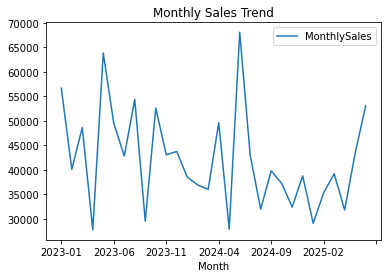

In [20]:
query = """
SELECT strftime('%Y-%m', Date) AS Month, SUM(TotalPrice) AS MonthlySales
FROM Orders
GROUP BY Month
ORDER BY Month;
"""
monthly_sales = pd.read_sql_query(query, conn)

monthly_sales.plot(x="Month", y="MonthlySales", kind="line", title="Monthly Sales Trend")


In [22]:
query = """
SELECT CustomerID, SUM(TotalPrice) AS TotalSpent
FROM Orders
GROUP BY CustomerID
ORDER BY TotalSpent DESC
LIMIT 5;
"""
pd.read_sql_query(query, conn)


,CustomerID,TotalSpent
0,C38840,5723.23
1,C57276,3456.40
2,C67260,3390.80
3,C13877,3384.90
4,C18404,3370.20
